# Offline run analysis with NeuroKit2 EOG-offset labels

This variant mirrors notebook 03, but sample-level true labels transition at the detected **end of EOG activity** after each audio cue. Audio cues are still used as ordering anchors for the alternating Eyes Open / Eyes Closed sequence; they are not used as the label transition time. EOG event onset/offset boundaries are produced by NeuroKit2 (`eog_clean` -> `eog_findpeaks` -> `eog_features`), whose EOG feature extraction returns BLINKER-style left/right zero crossings. Outputs are saved under `runs_offline_eog/<OFFLINE_RUN_ID>/`.


In [12]:
# imports 
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'training.py').exists():
    ROOT = Path(r'D:/BME/BCI/online_bci/online_eeg')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from preprocessing import (
    AudioLabelConfig,
    PreprocessConfig,
    labeled_preprocess_summary,
)
from eog_labeling import (
    EogOffsetLabelConfig,
    preprocess_recording_with_eog_offset_labels,
)
from training import (
    TrainingConfig,
    offline_train_test_sweep,
    rank_sweep_by_causal_delay,
    rank_sweep_summary,
    select_lowest_causal_delay_variant,
)
from testing import load_test_variant_artifacts
from plots import (
    plot_labeled_recording,
    plot_offline_variant_trace_and_xcov,
    plot_predictions_overlay,
    plot_xcov_curve,
)

print('Pipeline root:', ROOT)


Pipeline root: d:\BME\BCI\online_bci\online_eeg


## Raw files, preprocessing, and sweep settings


In [13]:
TRAIN_RUN_ID = 'run_002'
TEST_RUN_ID = 'run_003'
RUN_ID = TRAIN_RUN_ID  # Kept for titles and older cells.
RUNS_ROOT = ROOT / 'runs'
TRAIN_RUN_DIR = RUNS_ROOT / TRAIN_RUN_ID
TEST_RUN_DIR = RUNS_ROOT / TEST_RUN_ID

OFFLINE_RUN_ID = 'offline_eog_002_vs_003'  # Change this to keep a separate set of 03a outputs.
OFFLINE_ROOT = ROOT / 'runs_offline_eog'
OFFLINE_RUN_DIR = OFFLINE_ROOT / OFFLINE_RUN_ID

TRAIN_RAW_SUBDIR = 'raw_training'
TRAIN_RAW_PATTERN = f'{TRAIN_RUN_ID}_train.npz'
TRAIN_RAW_NPZ_OVERRIDE = None  # Set to a full Path/string to use any raw training .npz.

TEST_RAW_SUBDIR = 'raw_training'  # The EOG-offset notebook defaults to testing on another training-style run.
TEST_RAW_PATTERN = f'{TEST_RUN_ID}_train.npz'
TEST_RAW_NPZ_OVERRIDE = None  # Set to a full Path/string to use any raw test .npz.

def resolve_one_raw_npz(run_id, run_dir, subdir, pattern, override, label):
    if override is not None:
        path = Path(override)
        if not path.exists():
            raise FileNotFoundError(f'{label} raw override not found: {path}')
        return path
    if not run_dir.exists():
        raise FileNotFoundError(f'{label} run folder not found for {run_id}: {run_dir}')
    raw_dir = run_dir / subdir
    matches = sorted(path for path in raw_dir.glob(pattern) if path.is_file())
    if not matches:
        raise FileNotFoundError(
            f'No {label} raw files matched {raw_dir / pattern}. '
            'Adjust the run ID, subdir, pattern, or override path.'
        )
    if len(matches) > 1:
        raise ValueError(
            f'Multiple {label} raw files matched {raw_dir / pattern}: '
            + ', '.join(str(path) for path in matches)
            + '. Narrow the pattern or set the override path.'
        )
    return matches[0]

TRAIN_RAW_NPZ = resolve_one_raw_npz(
    TRAIN_RUN_ID,
    TRAIN_RUN_DIR,
    TRAIN_RAW_SUBDIR,
    TRAIN_RAW_PATTERN,
    TRAIN_RAW_NPZ_OVERRIDE,
    'training',
)
TEST_RAW_NPZ = resolve_one_raw_npz(
    TEST_RUN_ID,
    TEST_RUN_DIR,
    TEST_RAW_SUBDIR,
    TEST_RAW_PATTERN,
    TEST_RAW_NPZ_OVERRIDE,
    'test',
)

EEG_CHANNELS = (1, 2, 3, 4)
EOG_CHANNELS = (5,)  # Hardware channel(s) containing recorded EOG; stored and plotted separately from EEG.
EEG_CHANNEL_NAMES = ('O1', 'Oz', 'O2', 'POz')
AUDIO_CHANNEL = 16

APPLY_SOFTWARE_FILTERS = True  # BIOPAC hardware already bandpasses the EEG at 1-35 Hz.
DEMEAN_CHANNELS = True
SOFTWARE_BANDPASS_HZ = (8.0, 35.0)  # Set to (8.0, 35.0) to filter out blinks only if APPLY_SOFTWARE_FILTERS=True.
SOFTWARE_NOTCH_HZ = (60.0,)  # Set to (60.0,) only if APPLY_SOFTWARE_FILTERS=True.
PREPROCESS_TAG = 'software_filters_on' if APPLY_SOFTWARE_FILTERS else 'hardware_filter_only'
if DEMEAN_CHANNELS:
    PREPROCESS_TAG += '_demeaned'

OFFLINE_LABELED_DIR = OFFLINE_RUN_DIR / 'labeled'
TRAIN_LABELED_NPZ = OFFLINE_LABELED_DIR / f'{TRAIN_RUN_ID}__{TRAIN_RAW_NPZ.stem}_eog_offset_labeled.npz'
TEST_LABELED_NPZ = OFFLINE_LABELED_DIR / f'{TEST_RUN_ID}__{TEST_RAW_NPZ.stem}_eog_offset_labeled.npz'
SWEEP_DIR = OFFLINE_RUN_DIR / 'sweeps'

FEATURE_MODES = ('filtered_signal',)

WINDOW_SECS = (1.0, 2.0, 3)
STRIDE_SECS = (0.02, 0.05, 0.1, 0.2)
LABEL_MODES = ('endpoint', 'majority')  # Sweep both endpoint and majority window labels.
PLOT_DURATION_SEC = 60.0

PRE = PreprocessConfig(
    eeg_channels=EEG_CHANNELS,
    eog_channels=EOG_CHANNELS,
    audio_channel=AUDIO_CHANNEL,
    apply_software_filters=APPLY_SOFTWARE_FILTERS,
    bandpass_low_hz=None if SOFTWARE_BANDPASS_HZ is None else SOFTWARE_BANDPASS_HZ[0],
    bandpass_high_hz=None if SOFTWARE_BANDPASS_HZ is None else SOFTWARE_BANDPASS_HZ[1],
    notch_hz=SOFTWARE_NOTCH_HZ,
    notch_quality_factor=30.0,
    filter_order=4,
    demean_channels=DEMEAN_CHANNELS,
)

LABELS = AudioLabelConfig(
    class_names=('Eyes Open', 'Eyes Closed'),
    baseline_label=0,
    active_label=1,
    cue_label_sequence=None,
    alternate_binary_labels=True,
    label_duration_sec=None,  # transition mode: each EOG offset switches state until the next EOG offset.
    label_start_offset_sec=0.0,  # label switch starts exactly at EOG activity offset.
    envelope_window_sec=0.025,
    onset_threshold=None,
    onset_min_interval_sec=0.50,
)

# EOG detection settings. These control NeuroKit2 event detection and cue-to-EOG matching.
EOG_NEUROKIT_CLEAN_METHOD = 'neurokit'  # Cleaning method passed to nk.eog_clean before peak detection.
EOG_NEUROKIT_PEAK_METHOD = 'brainstorm'  # Peak detector passed to nk.eog_findpeaks; 'brainstorm' matched run_002/run_003 reliably.
EOG_DETECT_BOTH_POLARITIES = True  # Run detection on EOG and inverted EOG so upward and downward eye movements can both be found.
EOG_CHANNEL_INDEX = 0  # Index into EOG_CHANNELS used for detection; 0 means hardware channel 5 when EOG_CHANNELS = (5,).
EOG_MIN_ACTIVITY_DURATION_SEC = 0.05  # Drop NeuroKit events shorter than this duration in seconds.
EOG_MERGE_GAP_SEC = 0.30  # Merge adjacent NeuroKit events separated by no more than this many seconds.
EOG_SEARCH_START_OFFSET_SEC = 0.0  # Start cue-to-EOG matching this many seconds after each audio cue; negative allows pre-cue EOG.
EOG_SEARCH_MAX_SEC = 3.0  # Stop cue-to-EOG matching this many seconds after each audio cue.
EOG_END_BEFORE_NEXT_CUE_SEC = 0.20  # Do not match an EOG event whose endpoint is within this margin of the next audio cue.
EOG_LABEL_OFFSET_SEC = 0.0  # Shift the final label transition relative to the NeuroKit EOG offset; 0 uses the offset exactly.
EOG_FALLBACK_TO_AUDIO_ONSET = True  # If True, use audio cue time when no matching EOG event is found; False raises an error.

EOG_LABELS = EogOffsetLabelConfig(
    neurokit_clean_method=EOG_NEUROKIT_CLEAN_METHOD,
    neurokit_peak_method=EOG_NEUROKIT_PEAK_METHOD,
    detect_both_polarities=EOG_DETECT_BOTH_POLARITIES,
    eog_channel_index=EOG_CHANNEL_INDEX,
    min_activity_duration_sec=EOG_MIN_ACTIVITY_DURATION_SEC,
    merge_gap_sec=EOG_MERGE_GAP_SEC,
    search_start_offset_sec=EOG_SEARCH_START_OFFSET_SEC,
    search_max_sec=EOG_SEARCH_MAX_SEC,
    end_before_next_cue_sec=EOG_END_BEFORE_NEXT_CUE_SEC,
    label_offset_sec=EOG_LABEL_OFFSET_SEC,
    fallback_to_audio_onset=EOG_FALLBACK_TO_AUDIO_ONSET,
)

TRAIN = TrainingConfig(
    train_fraction=1.0,
    # hidden_size=256,
    hidden_size=64,
    num_layers=1,
    dropout=0.2,
    batch_size=64,
    epochs=20,
    lr=1e-3,
    seed=888,
)

OFFLINE_LABELED_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_DIR.mkdir(parents=True, exist_ok=True)
print('Training run ID:', TRAIN_RUN_ID)
print('Test run ID:', TEST_RUN_ID)
print('Offline root:', OFFLINE_ROOT)
print('Offline run directory:', OFFLINE_RUN_DIR)
print('Training raw file:', TRAIN_RAW_NPZ)
print('Test raw file:', TEST_RAW_NPZ)
print('Offline labeled output:', OFFLINE_LABELED_DIR)
print('Sweep output:', SWEEP_DIR)
print('Preprocess tag:', PREPROCESS_TAG)
print('Software filters enabled:', APPLY_SOFTWARE_FILTERS)
print('EOG label source: NeuroKit2 EOG event offset after each audio cue')
print('EOG label config:', EOG_LABELS)


Training run ID: run_002
Test run ID: run_003
Offline root: d:\BME\BCI\online_bci\online_eeg\runs_offline_eog
Offline run directory: d:\BME\BCI\online_bci\online_eeg\runs_offline_eog\offline_eog_002_vs_003
Training raw file: d:\BME\BCI\online_bci\online_eeg\runs\run_002\raw_training\run_002_train.npz
Test raw file: d:\BME\BCI\online_bci\online_eeg\runs\run_003\raw_training\run_003_train.npz
Offline labeled output: d:\BME\BCI\online_bci\online_eeg\runs_offline_eog\offline_eog_002_vs_003\labeled
Sweep output: d:\BME\BCI\online_bci\online_eeg\runs_offline_eog\offline_eog_002_vs_003\sweeps
Preprocess tag: software_filters_on_demeaned
Software filters enabled: True
EOG label source: NeuroKit2 EOG event offset after each audio cue
EOG label config: EogOffsetLabelConfig(neurokit_clean_method='neurokit', neurokit_peak_method='brainstorm', detect_both_polarities=True, eog_channel_index=0, min_activity_duration_sec=0.05, merge_gap_sec=0.3, search_start_offset_sec=0.0, search_max_sec=3.0, end_bef

## Preprocess raw files with EOG-offset labels


In [14]:
TRAIN_LABELED_NPZ, train_cue_table = preprocess_recording_with_eog_offset_labels(
    raw_npz=TRAIN_RAW_NPZ,
    output_npz=TRAIN_LABELED_NPZ,
    preprocess_config=PRE,
    label_config=LABELS,
    eog_label_config=EOG_LABELS,
)
TEST_LABELED_NPZ, test_cue_table = preprocess_recording_with_eog_offset_labels(
    raw_npz=TEST_RAW_NPZ,
    output_npz=TEST_LABELED_NPZ,
    preprocess_config=PRE,
    label_config=LABELS,
    eog_label_config=EOG_LABELS,
)

preprocess_summary = labeled_preprocess_summary({
    'training': TRAIN_LABELED_NPZ,
    'test': TEST_LABELED_NPZ,
})
display(preprocess_summary)

print('Training EOG-offset event table')
display(train_cue_table)
print('Test EOG-offset event table')
display(test_cue_table)


,name,path,samplerate,duration_sec,has_preprocess_config,has_apply_software_filters_flag,apply_software_filters,demean_channels,bandpass_low_hz,bandpass_high_hz,notch_hz,eeg_channels,eog_channels,requested_eog_channels,missing_eog_channels,audio_channel,source_raw_npz
0,training,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,200,300.0,True,True,True,True,8.0,35.0,[60.0],"[1, 2, 3, 4]","(5,)",[5],(),16,d:\BME\BCI\online_bci\online_eeg\runs\run_002\...
1,test,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,200,300.0,True,True,True,True,8.0,35.0,[60.0],"[1, 2, 3, 4]","(5,)",[5],(),16,d:\BME\BCI\online_bci\online_eeg\runs\run_003\...


Training EOG-offset event table


,cue_index,audio_onset_sample,audio_onset_time_sec,eog_activity_start_sample,eog_activity_start_time_sec,eog_activity_end_sample,eog_activity_end_time_sec,neurokit_peak_sample,neurokit_peak_time_sec,neurokit_peak_value,...,used_audio_fallback,eog_label_event_sample,eog_label_event_time_sec,label_start_sample,label_end_sample,label_start_time_sec,label_end_time_sec,label,label_name,eog_activity_peak_value_label
0,0,1428,7.140,1683,8.415,1882,9.410,1783,8.915,0.555806,...,False,1882,9.410,1882,3881,9.410,19.405,1,Eyes Closed,0.555806
1,1,3675,18.375,3675,18.375,3881,19.405,3753,18.765,1.304490,...,False,3881,19.405,3881,5401,19.405,27.005,0,Eyes Open,1.304490
2,2,5251,26.255,5281,26.405,5401,27.005,5302,26.510,1.275995,...,False,5401,27.005,5401,6368,27.005,31.840,1,Eyes Closed,1.275995
3,3,6179,30.895,6179,30.895,6368,31.840,6204,31.020,1.112312,...,False,6368,31.840,6368,8175,31.840,40.875,0,Eyes Open,1.112312
4,4,8011,40.055,8011,40.055,8175,40.875,8076,40.380,1.031946,...,False,8175,40.875,8175,9824,40.875,49.120,1,Eyes Closed,1.031946
5,5,9635,48.175,9635,48.175,9824,49.120,9664,48.320,1.127616,...,False,9824,49.120,9824,11552,49.120,57.760,0,Eyes Open,1.127616
6,6,11287,56.435,11459,57.295,11552,57.760,11500,57.500,1.291824,...,False,11552,57.760,11552,13782,57.760,68.910,1,Eyes Closed,1.291824
7,7,13619,68.095,13619,68.095,13782,68.910,13683,68.415,1.109193,...,False,13782,68.910,13782,14696,68.910,73.480,0,Eyes Open,1.109193
8,8,14479,72.395,14479,72.395,14696,73.480,14597,72.985,1.454765,...,False,14696,73.480,14696,15806,73.480,79.030,1,Eyes Closed,1.454765
9,9,15651,78.255,15651,78.255,15806,79.030,15707,78.535,1.040661,...,False,15806,79.030,15806,17729,79.030,88.645,0,Eyes Open,1.040661


Test EOG-offset event table


,cue_index,audio_onset_sample,audio_onset_time_sec,eog_activity_start_sample,eog_activity_start_time_sec,eog_activity_end_sample,eog_activity_end_time_sec,neurokit_peak_sample,neurokit_peak_time_sec,neurokit_peak_value,...,used_audio_fallback,eog_label_event_sample,eog_label_event_time_sec,label_start_sample,label_end_sample,label_start_time_sec,label_end_time_sec,label,label_name,eog_activity_peak_value_label
0,0,3270,16.350,3270,16.350,3500,17.500,3401,17.005,1.161624,...,False,3500,17.500,3500,6392,17.500,31.960,1,Eyes Closed,1.161624
1,1,6177,30.885,6177,30.885,6392,31.960,6293,31.465,1.029298,...,False,6392,31.960,6392,7547,31.960,37.735,0,Eyes Open,1.029298
2,2,7357,36.785,7357,36.785,7547,37.735,7390,36.950,0.970331,...,False,7547,37.735,7547,8792,37.735,43.960,1,Eyes Closed,0.970331
3,3,8588,42.940,8588,42.940,8792,43.960,8693,43.465,1.107942,...,False,8792,43.960,8792,10396,43.960,51.980,0,Eyes Open,1.107942
4,4,10180,50.900,10180,50.900,10396,51.980,10211,51.055,1.049364,...,False,10396,51.980,10396,12014,51.980,60.070,1,Eyes Closed,1.049364
5,5,11832,59.160,11832,59.160,12014,60.070,11866,59.330,0.995830,...,False,12014,60.070,12014,13276,60.070,66.380,0,Eyes Open,0.995830
6,6,13069,65.345,13069,65.345,13276,66.380,13177,65.885,0.973368,...,False,13276,66.380,13276,14429,66.380,72.145,1,Eyes Closed,0.973368
7,7,14232,71.160,14232,71.160,14429,72.145,14330,71.650,0.975349,...,False,14429,72.145,14429,15486,72.145,77.430,0,Eyes Open,0.975349
8,8,15264,76.320,15264,76.320,15486,77.430,15387,76.935,0.969598,...,False,15486,77.430,15486,16421,77.430,82.105,1,Eyes Closed,0.969598
9,9,16256,81.280,16256,81.280,16421,82.105,16322,81.610,0.900798,...,False,16421,82.105,16421,17922,82.105,89.610,0,Eyes Open,0.900798


## Inspect freshly labeled train/test data


Text(0.5, 1.0, 'Training EOG-offset labeled EEG preview')

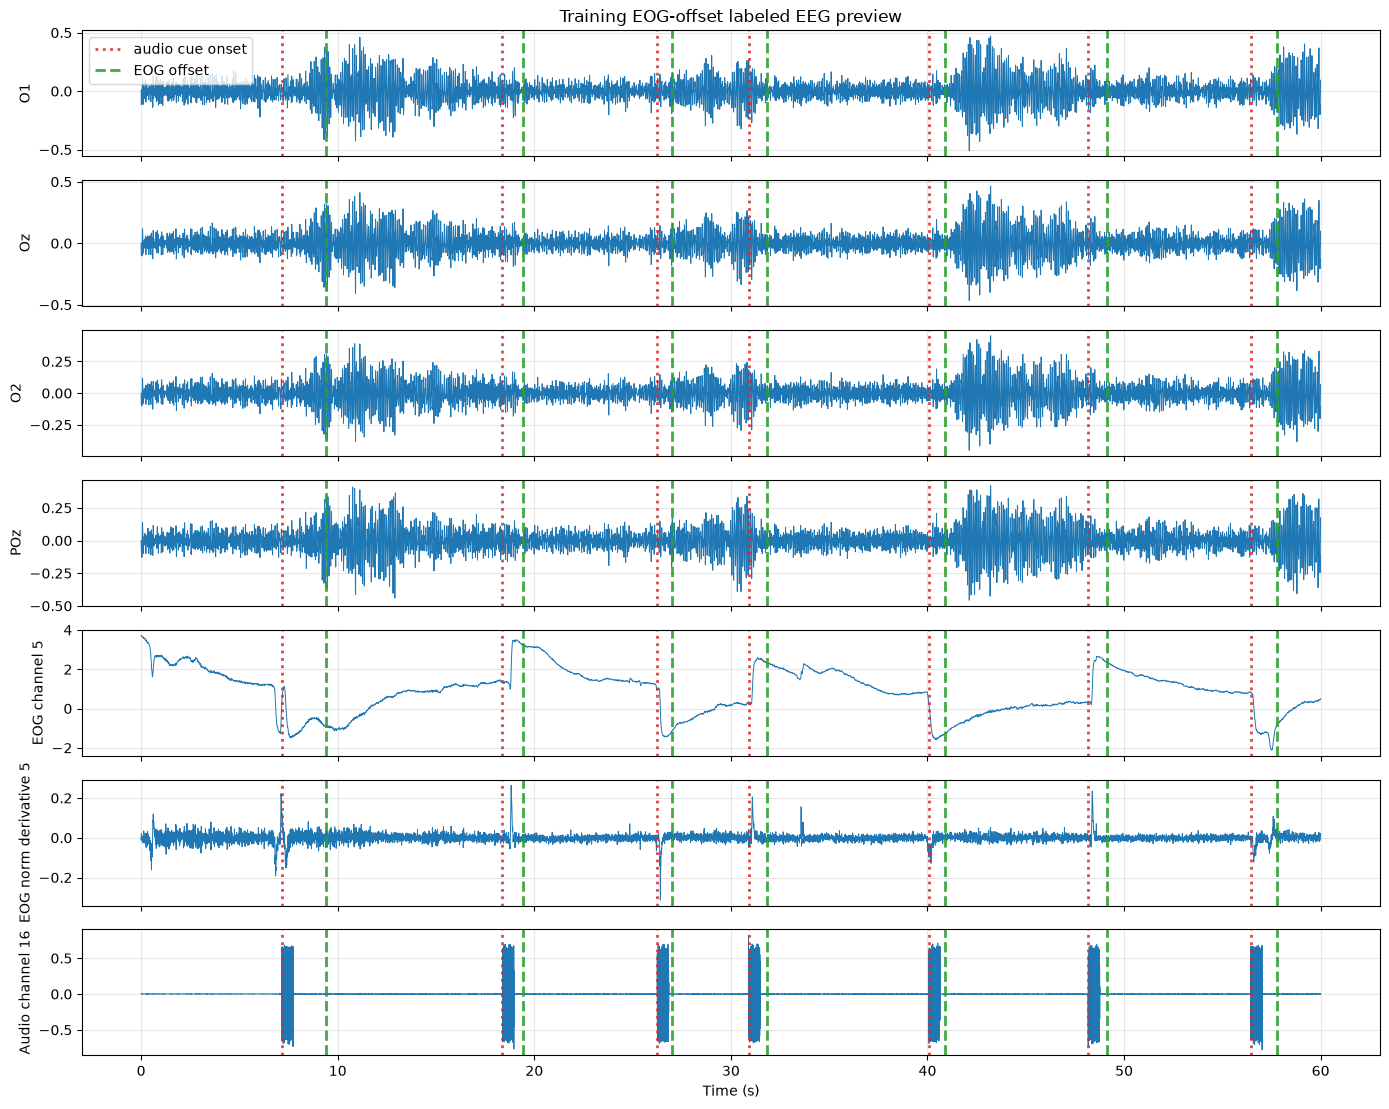

In [15]:
fig, axes = plot_labeled_recording(
    TRAIN_LABELED_NPZ,
    max_duration_sec=PLOT_DURATION_SEC,
    channel_names=EEG_CHANNEL_NAMES,
)
axes[0].set_title('Training EOG-offset labeled EEG preview')


Text(0.5, 1.0, 'Test EOG-offset labeled EEG preview')

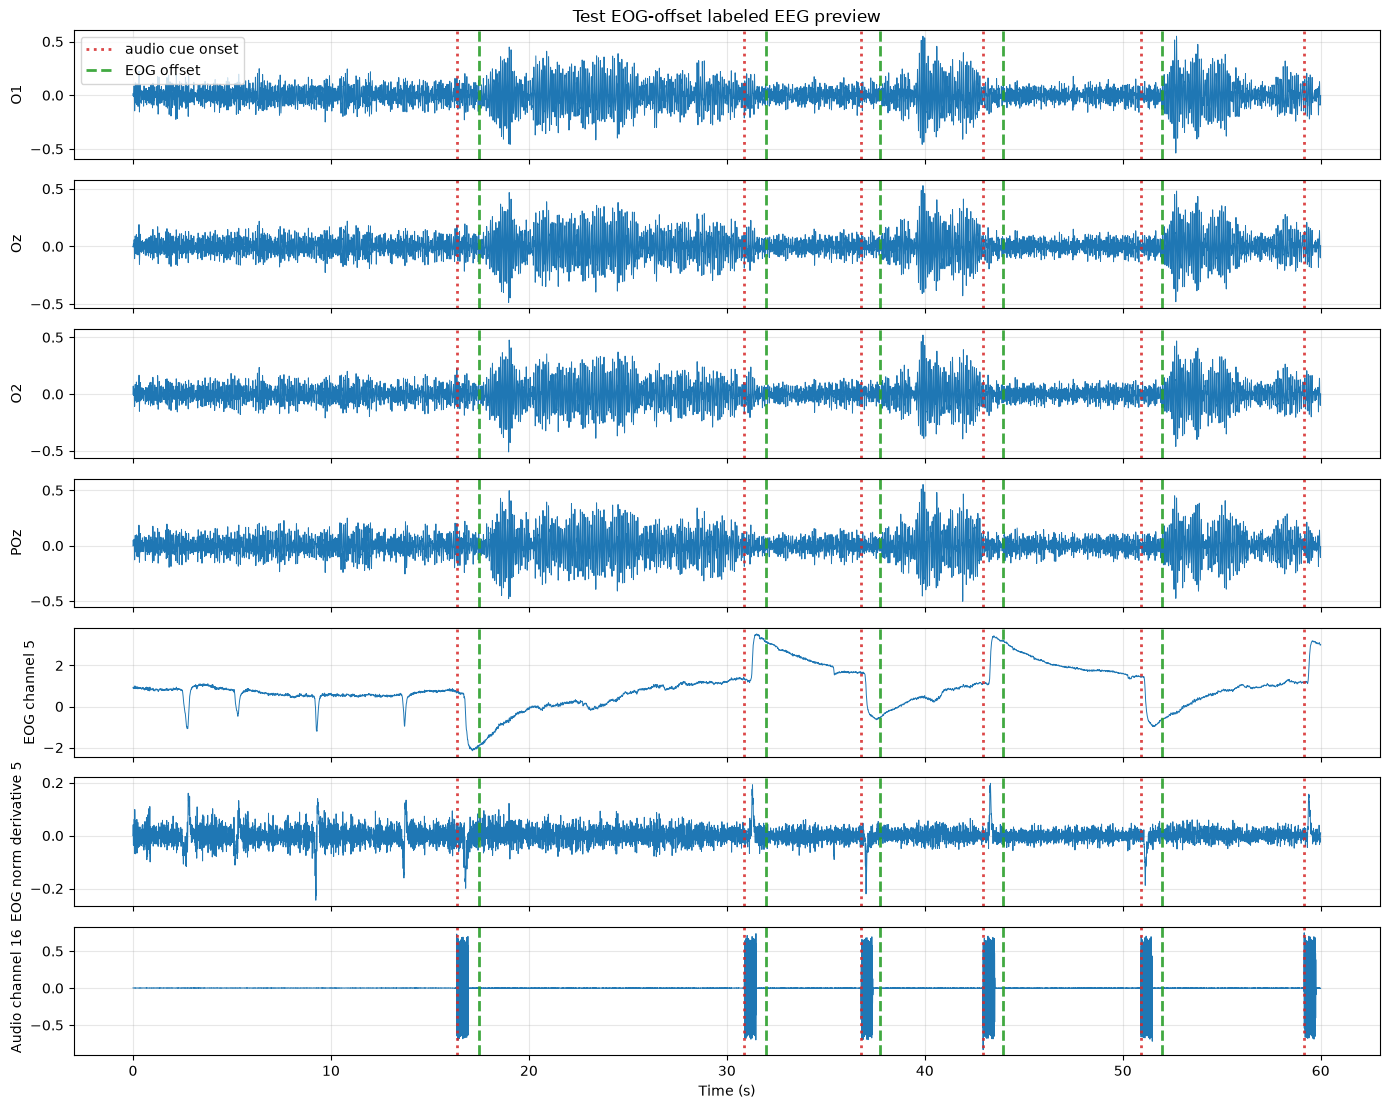

In [16]:
fig, axes = plot_labeled_recording(
    TEST_LABELED_NPZ,
    max_duration_sec=PLOT_DURATION_SEC,
    channel_names=EEG_CHANNEL_NAMES,
)
axes[0].set_title('Test EOG-offset labeled EEG preview')


## Run offline model sweep


In [17]:
sweep_result = offline_train_test_sweep(
    train_labeled_npz=TRAIN_LABELED_NPZ,
    test_labeled_npz=TEST_LABELED_NPZ,
    output_dir=SWEEP_DIR,
    feature_modes=FEATURE_MODES,
    window_secs=WINDOW_SECS,
    stride_secs=STRIDE_SECS,
    training_config=TRAIN,
    label_modes=LABEL_MODES,
)

RANK_COLUMN = 'test_xcov_peak_coeff'
summary = rank_sweep_summary(sweep_result['summary'], rank_column=RANK_COLUMN)
print('Saved sweep summary:', sweep_result['summary_csv'])
print(f'Ranked variants by {RANK_COLUMN} descending; balanced accuracy is used only as a tie-breaker.')
display(summary)


Saved sweep summary: d:\BME\BCI\online_bci\online_eeg\runs_offline_eog\offline_eog_002_vs_003\sweeps\offline_sweep_summary.csv
Ranked variants by test_xcov_peak_coeff descending; balanced accuracy is used only as a tie-breaker.


,variant,feature_mode,label_mode,window_sec,stride_sec,checkpoint_path,variant_dir,validation_aligned_prediction_csv,test_aligned_prediction_csv,val_accuracy,...,test_n_windows,test_mean_cue_to_first_correct_sec,test_median_cue_to_first_correct_sec,test_mean_cue_to_predicted_transition_sec,test_median_cue_to_predicted_transition_sec,test_mean_cue_to_sustained_prediction_sec,test_median_cue_to_sustained_prediction_sec,test_xcov_delay_sec,test_xcov_peak_coeff,test_xcov_signal_column
0,filtered_signal__win_3s__stride_0p05s__labels_...,filtered_signal,endpoint,3.0,0.05,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,1.0,...,5941.0,0.238250,0.0475,0.768571,0.2325,0.348250,0.1000,0.040,0.803805,prob_Eyes Closed
1,filtered_signal__win_3s__stride_0p02s__labels_...,filtered_signal,endpoint,3.0,0.02,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,1.0,...,14851.0,0.130000,0.0150,1.611346,0.3300,0.130000,0.0150,-0.080,0.795910,prob_Eyes Closed
2,filtered_signal__win_2p0s__stride_0p05s__label...,filtered_signal,majority,2.0,0.05,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,1.0,...,5961.0,0.168250,0.0400,1.402969,0.3200,0.174500,0.0400,-0.015,0.792908,prob_Eyes Closed
3,filtered_signal__win_1p0s__stride_0p05s__label...,filtered_signal,endpoint,1.0,0.05,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,1.0,...,5981.0,0.139500,0.0300,1.964667,1.3175,0.139500,0.0300,-0.230,0.787109,prob_Eyes Closed
4,filtered_signal__win_2p0s__stride_0p1s__labels...,filtered_signal,majority,2.0,0.10,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,1.0,...,2981.0,0.162000,0.0600,1.836333,1.4000,0.177000,0.0600,-0.260,0.778020,prob_Eyes Closed
5,filtered_signal__win_2p0s__stride_0p02s__label...,filtered_signal,endpoint,2.0,0.02,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,1.0,...,14901.0,0.122000,0.0100,1.893667,1.3025,0.123000,0.0100,-0.215,0.776709,prob_Eyes Closed
6,filtered_signal__win_1p0s__stride_0p02s__label...,filtered_signal,endpoint,1.0,0.02,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,1.0,...,14951.0,0.111000,0.0100,2.196129,1.3750,0.111000,0.0100,-0.205,0.773534,prob_Eyes Closed
7,filtered_signal__win_1p0s__stride_0p1s__labels...,filtered_signal,endpoint,1.0,0.10,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,1.0,...,2991.0,0.172000,0.0775,0.904483,0.2700,0.189500,0.0775,-0.030,0.758556,prob_Eyes Closed
8,filtered_signal__win_2p0s__stride_0p1s__labels...,filtered_signal,endpoint,2.0,0.10,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,d:\BME\BCI\online_bci\online_eeg\runs_offline_...,1.0,...,2981.0,0.399500,0.2475,0.600882,0.3325,0.464500,0.3175,0.190,0.758330,prob_Eyes Closed
9,filtered_signal__win_3s__stride_0p1s__labels_m...,filtered_signal,majorit

## Compare variants


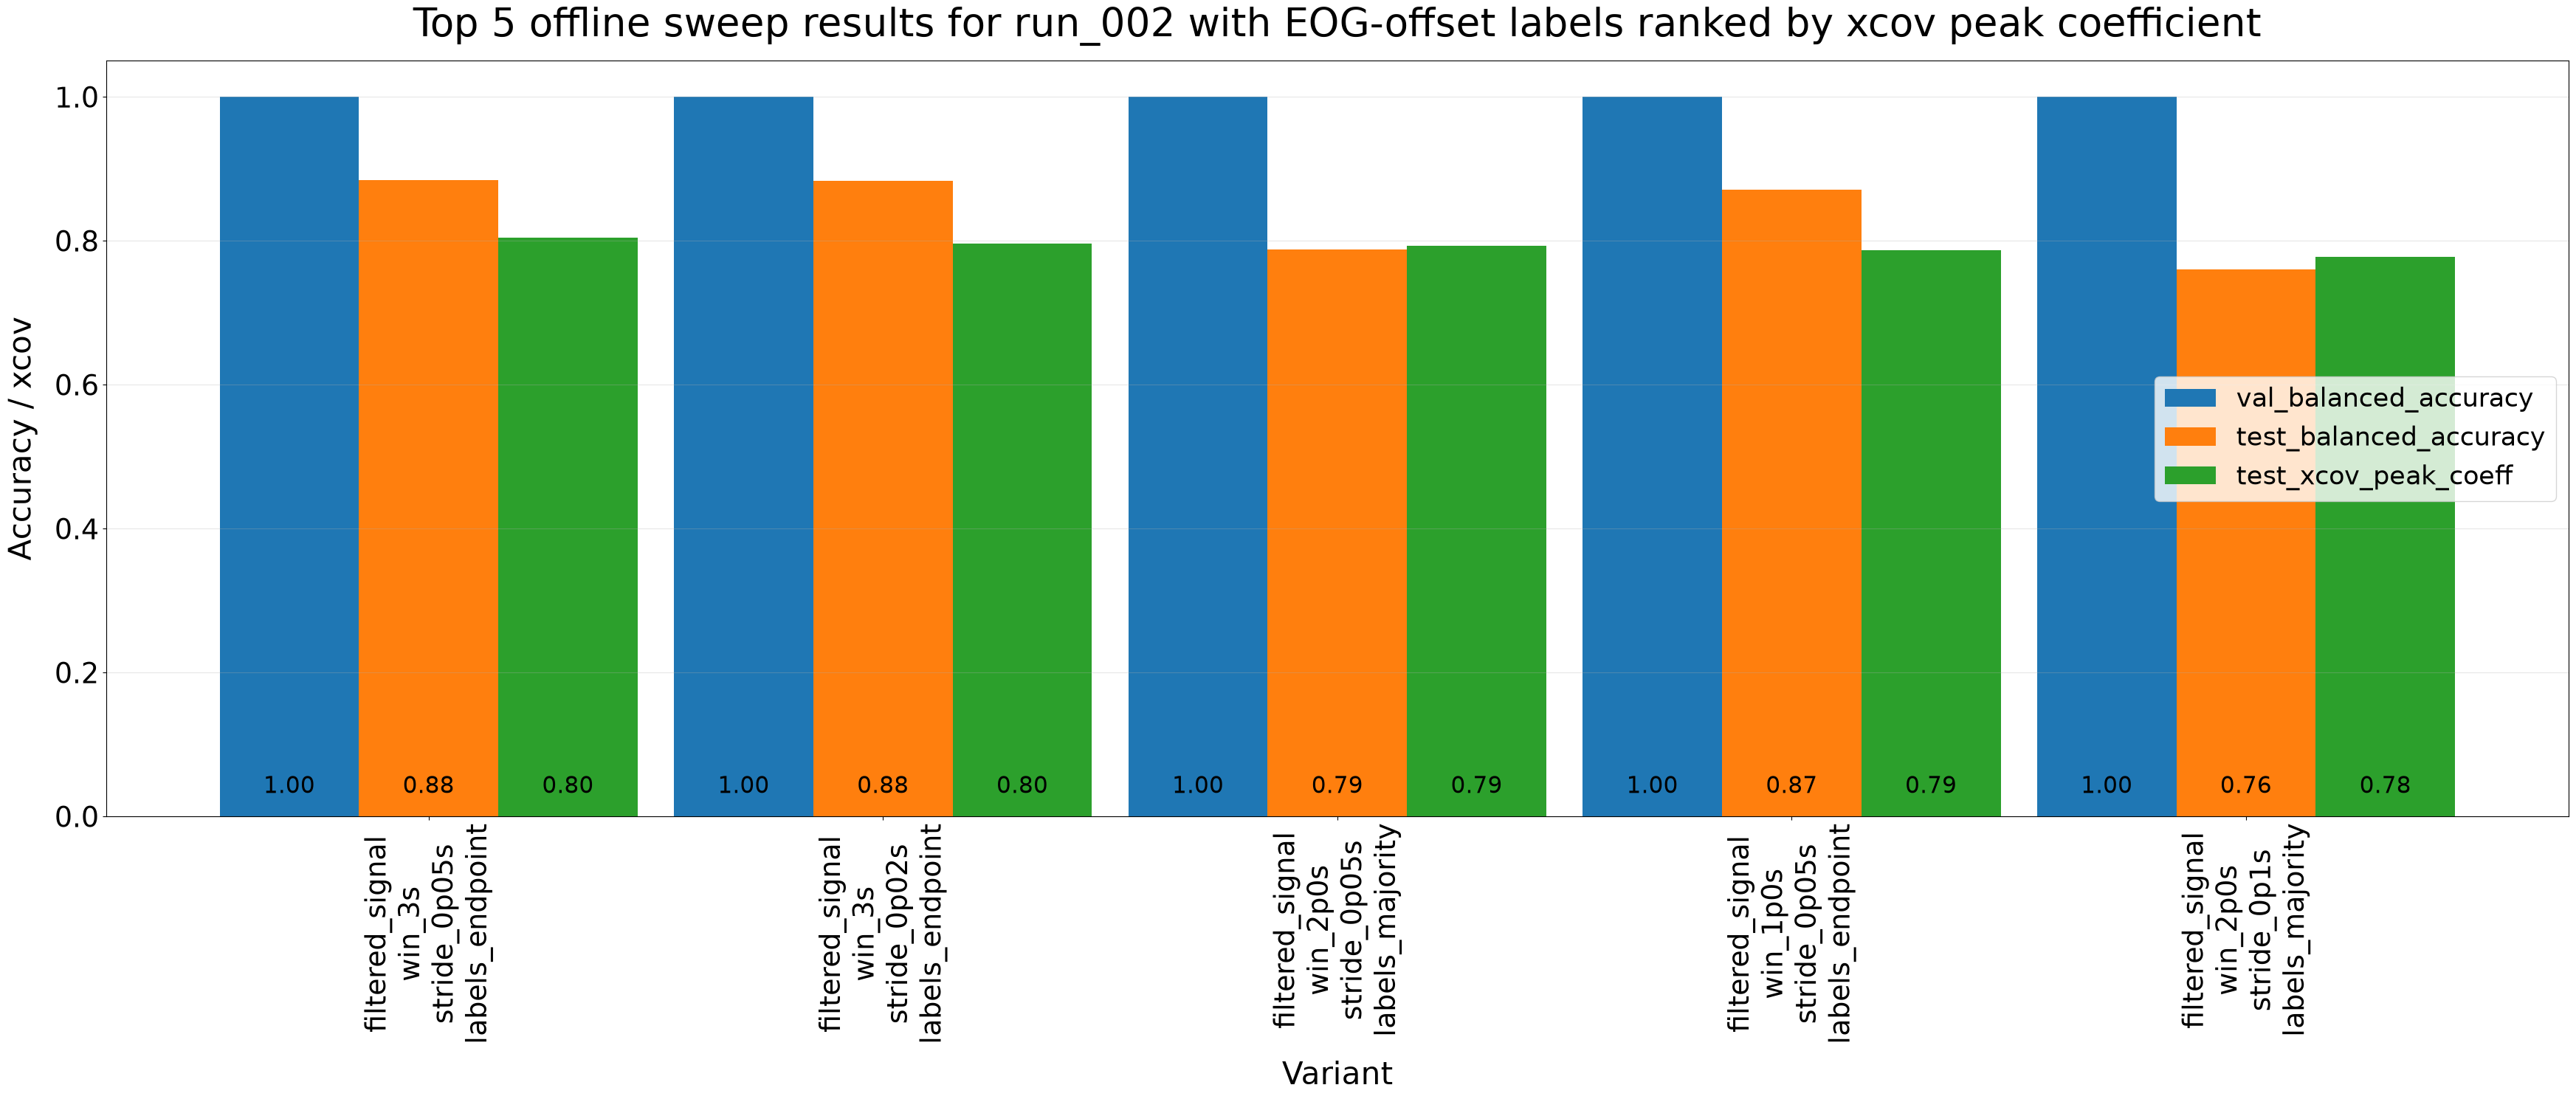

In [18]:
TOP_N_VARIANTS = 5
plot_df = summary.head(TOP_N_VARIANTS).copy()
plot_df['variant_short'] = plot_df['variant'].str.replace('__', '\n', regex=False)
plot_df['test_xcov_peak_coeff'] = pd.to_numeric(plot_df['test_xcov_peak_coeff'], errors='coerce')
ax = plot_df.plot.bar(
    x='variant_short',
    y=['val_balanced_accuracy', 'test_balanced_accuracy', 'test_xcov_peak_coeff'],
    figsize=(35, 15),
    width=0.92,
)
ax.set_xlabel('Variant', fontsize=30, labelpad=16)
ax.set_ylabel('Accuracy / xcov', fontsize=30, labelpad=16)
ax.set_ylim(0.0, 1.05)
ax.set_title(
    f'Top {TOP_N_VARIANTS} offline sweep results for {RUN_ID} with EOG-offset labels ranked by xcov peak coefficient',
    fontsize=38,
    pad=24,
)
ax.tick_params(axis='x', labelsize=27, rotation=90)
ax.tick_params(axis='y', labelsize=27)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if pd.notna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                0.025,
                f'{float(height):.2f}',
                ha='center',
                va='bottom',
                fontsize=22,
                color='black',
                clip_on=True,
            )
ax.legend(fontsize=25, loc='center right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()


## Inspect best variant predictions


Best variant by xcov peak coefficient: filtered_signal__win_3s__stride_0p05s__labels_endpoint
Best xcov peak coefficient: 0.803804705800033
Best xcov delay sec: 0.04
Best predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline_eog\offline_eog_002_vs_003\sweeps\filtered_signal__win_3s__stride_0p05s__labels_endpoint\run_003__run_003_train_eog_offset_labeled_test_predictions.csv
Best aligned EEG/predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline_eog\offline_eog_002_vs_003\sweeps\filtered_signal__win_3s__stride_0p05s__labels_endpoint\run_003__run_003_train_eog_offset_labeled_test_predictions_aligned_eeg.csv


,start_sample,end_sample,start_time_sec,end_time_sec,label,true_label,pred_label,correct,prob_Eyes Open,prob_Eyes Closed
5936,59360,59960,296.80,299.80,0,0,0,True,0.910778,0.089222
5937,59370,59970,296.85,299.85,0,0,0,True,0.912547,0.087452
5938,59380,59980,296.90,299.90,0,0,0,True,0.911439,0.088561
5939,59390,59990,296.95,299.95,0,0,0,True,0.909778,0.090222
5940,59400,60000,297.00,300.00,0,0,0,True,0.911819,0.088181


,n_cues,n_matched_first_correct,mean_cue_to_first_correct_sec,median_cue_to_first_correct_sec,n_matched_predicted_transition,mean_cue_to_predicted_transition_sec,median_cue_to_predicted_transition_sec,n_matched_sustained,mean_cue_to_sustained_prediction_sec,median_cue_to_sustained_prediction_sec
0,40,40,0.23825,0.0475,28,0.768571,0.2325,40,0.34825,0.1


,target_label,target_label_name,prediction_signal_column,xcov_delay_sec,xcov_lag_samples,xcov_peak_coeff,max_lag_sec,n_valid_samples
0,1,Eyes Closed,prob_Eyes Closed,0.04,8,0.803805,10.0,59400


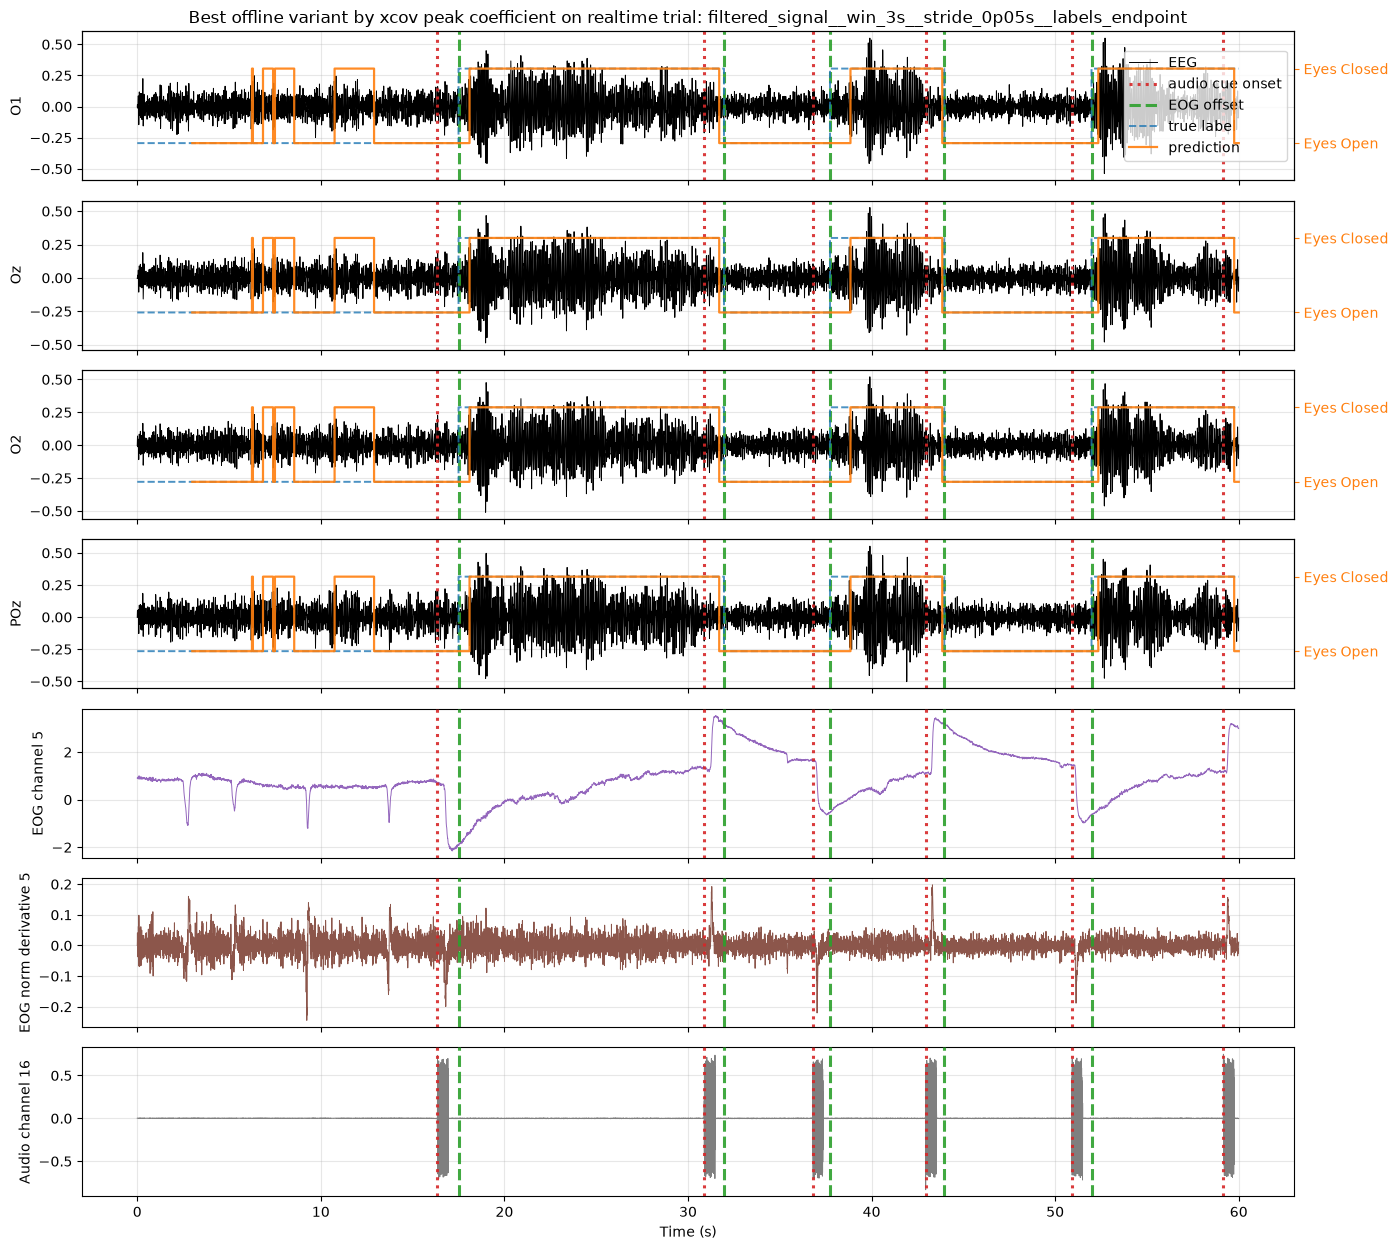

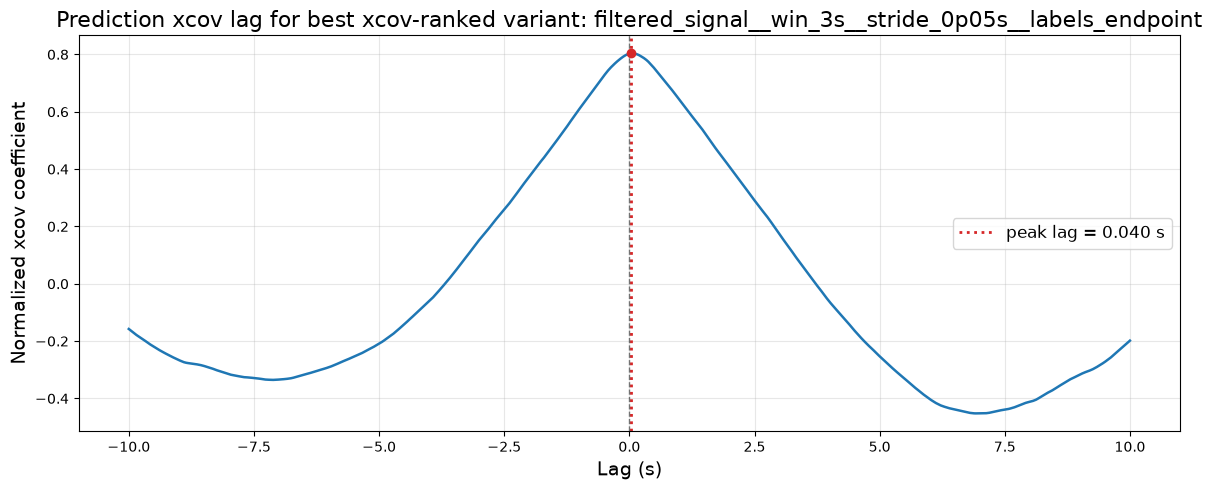

In [19]:
best = summary.iloc[0]
best_artifacts = load_test_variant_artifacts(best, TEST_LABELED_NPZ)
best_paths = best_artifacts['paths']
best_predictions = best_artifacts['predictions']
best_cue_delay_summary = best_artifacts['cue_delay_summary']
best_xcov_delay_summary = best_artifacts['xcov_delay_summary']
best_xcov_curve = best_artifacts['xcov_curve']

print('Best variant by xcov peak coefficient:', best['variant'])
print('Best xcov peak coefficient:', best.get('test_xcov_peak_coeff'))
print('Best xcov delay sec:', best.get('test_xcov_delay_sec'))
print('Best predictions:', best_paths['prediction_csv'])
print('Best aligned EEG/predictions:', best_paths['aligned_prediction_csv'])

display(best_predictions.tail())
if best_cue_delay_summary is not None:
    display(best_cue_delay_summary)
if best_xcov_delay_summary is not None:
    display(best_xcov_delay_summary)

fig, axes = plot_predictions_overlay(
    TEST_LABELED_NPZ,
    best_predictions,
    max_duration_sec=PLOT_DURATION_SEC,
    channel_names=EEG_CHANNEL_NAMES,
    show_true_labels=True,
    legend_loc='center right',
)
axes[0].set_title(f"Best offline variant by xcov peak coefficient on realtime trial: {best['variant']}")

if best_xcov_curve is not None and best_xcov_delay_summary is not None:
    fig, ax = plot_xcov_curve(
        best_xcov_curve,
        best_xcov_delay_summary,
        title=f"Prediction xcov lag for best xcov-ranked variant: {best['variant']}",
    )


## Compare variants by causal delay

The xcov lag is signed: positive delay means the prediction trace lags the label trace, while negative delay means the prediction trace leads the label trace. For a causal real-time model, negative delay should not be rewarded in the main delay ranking. This plot ranks variants with nonnegative xcov delay first, because those represent predictions that follow the label transition. Negative-delay variants remain in the full summary table but are placed after all nonnegative-delay variants here.


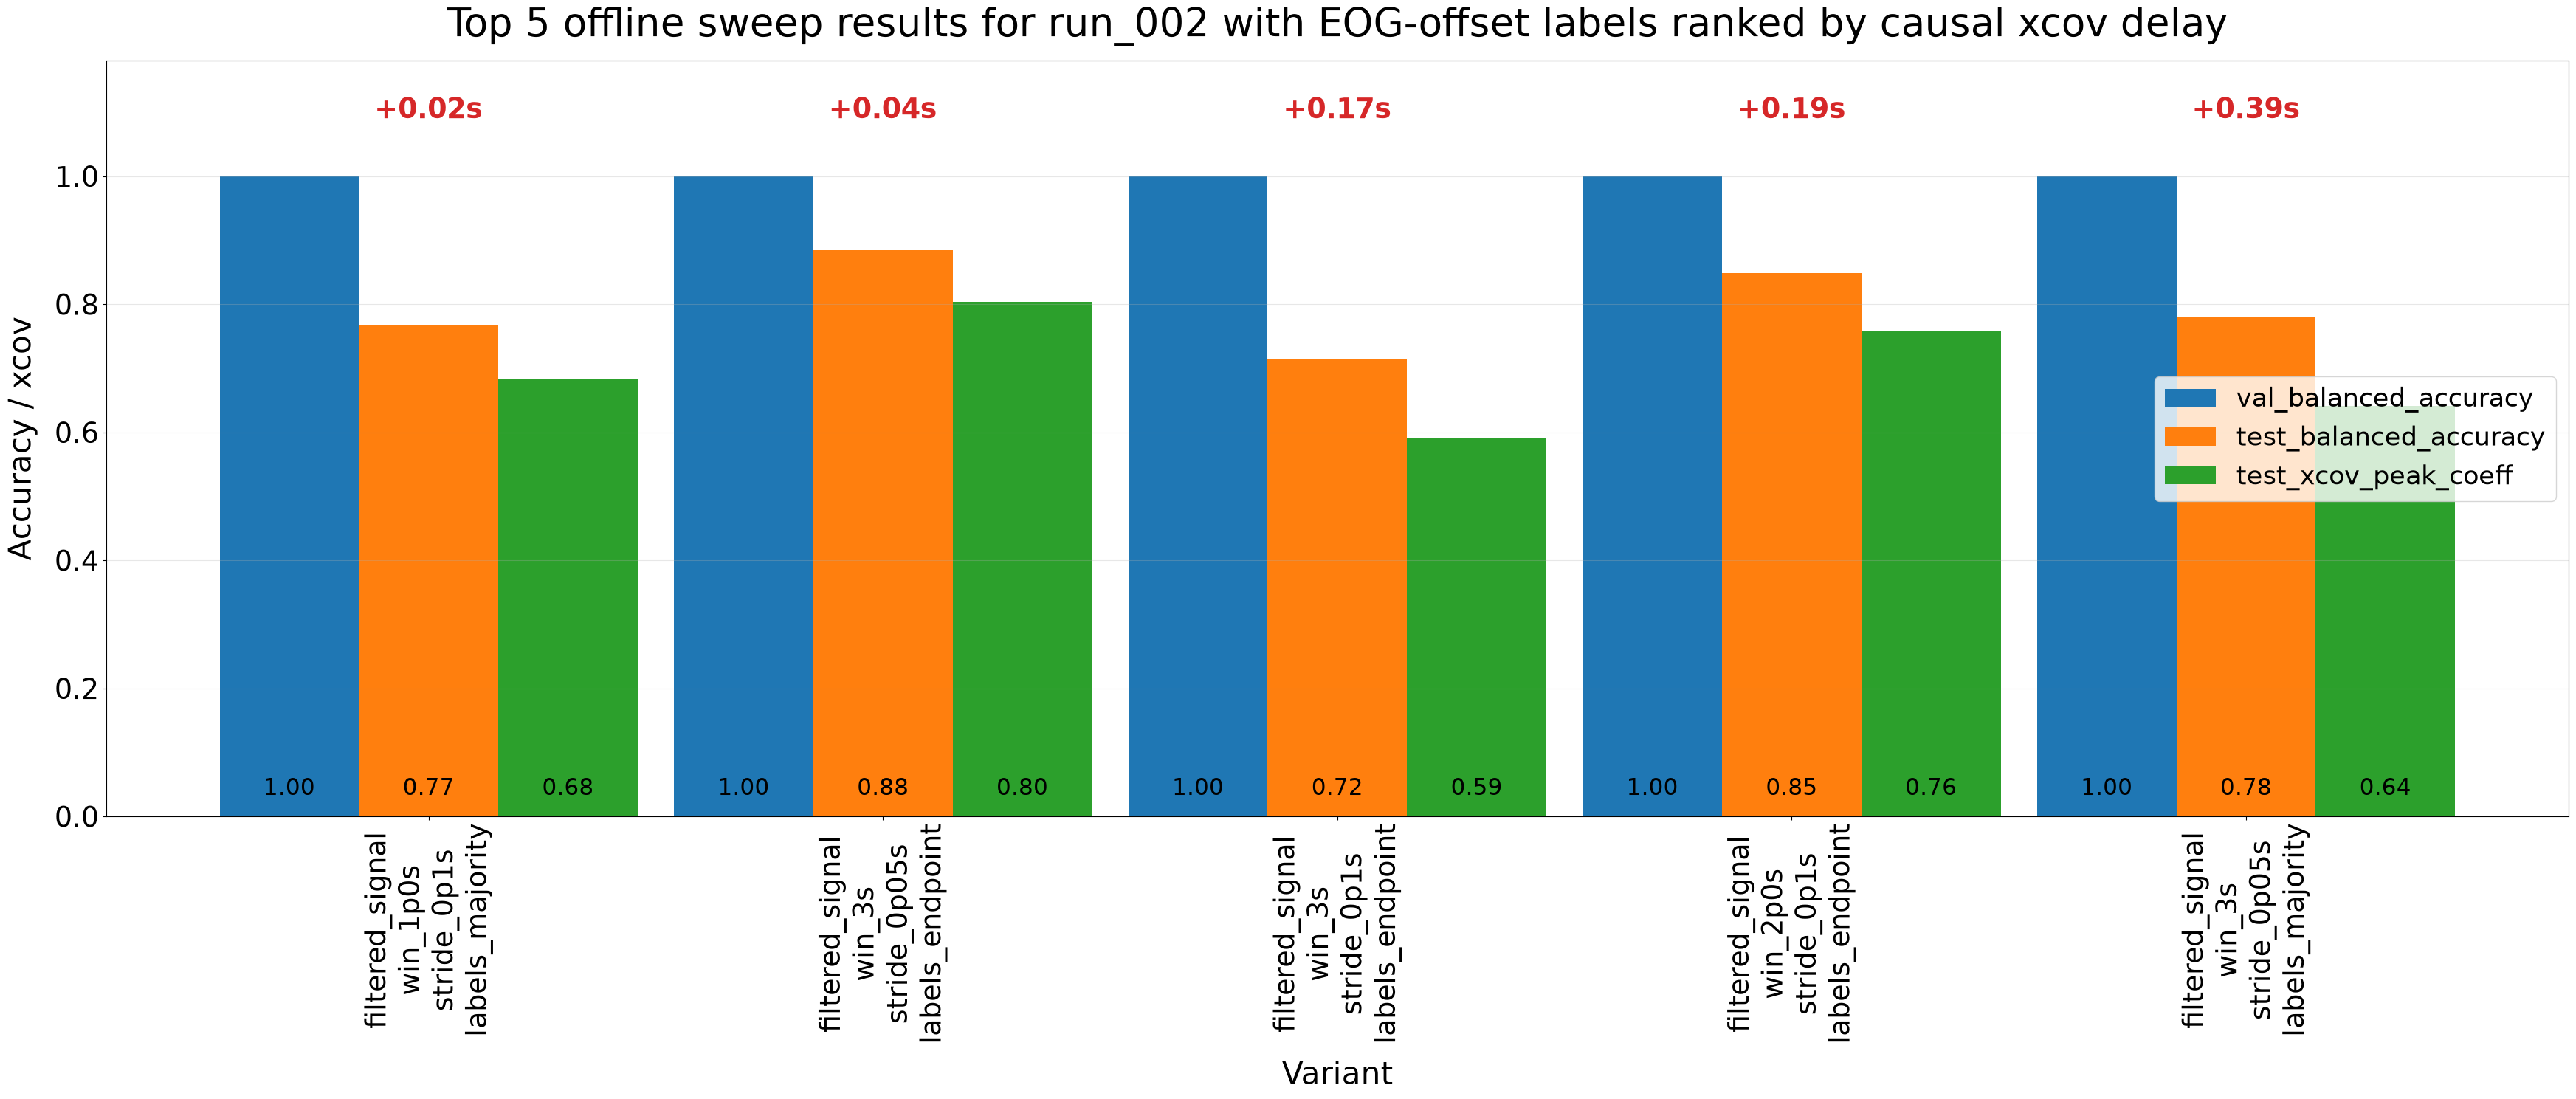

In [20]:
DELAY_TOP_N_VARIANTS = 5
delay_plot_df = rank_sweep_by_causal_delay(summary).head(DELAY_TOP_N_VARIANTS).copy()
delay_plot_df['variant_short'] = delay_plot_df['variant'].str.replace('__', '\n', regex=False)

ax = delay_plot_df.plot.bar(
    x='variant_short',
    y=['val_balanced_accuracy', 'test_balanced_accuracy', 'test_xcov_peak_coeff'],
    figsize=(35, 15),
    width=0.92,
)
ax.set_xlabel('Variant', fontsize=30, labelpad=16)
ax.set_ylabel('Accuracy / xcov', fontsize=30, labelpad=16)
ax.set_ylim(0.0, 1.18)
ax.set_title(
    f'Top {DELAY_TOP_N_VARIANTS} offline sweep results for {RUN_ID} with EOG-offset labels ranked by causal xcov delay',
    fontsize=38,
    pad=24,
)
ax.tick_params(axis='x', labelsize=27, rotation=90)
ax.tick_params(axis='y', labelsize=27)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if pd.notna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                0.025,
                f'{float(height):.2f}',
                ha='center',
                va='bottom',
                fontsize=22,
                color='black',
                clip_on=True,
            )
ax.legend(fontsize=25, loc='center right')
ax.grid(True, axis='y', alpha=0.3)

for idx, value in enumerate(delay_plot_df['test_xcov_delay_sec']):
    if pd.notna(value):
        ax.text(
            idx,
            1.08,
            f'{float(value):+.2f}s',
            ha='center',
            va='bottom',
            fontsize=27,
            color='tab:red',
            fontweight='bold',
        )
plt.tight_layout()


## Inspect lowest causal-delay variant predictions

This repeats the same diagnostic printouts and plots for the fastest valid causal-delay combination. Negative xcov delays are excluded from this selection because a negative delay means the prediction trace leads the true label trace, which should not be treated as real-time prediction latency.


Lowest causal-delay variant: filtered_signal__win_1p0s__stride_0p1s__labels_majority
Lowest causal xcov delay sec: 0.02
Lowest causal-delay xcov peak coefficient: 0.6829843334250383
Lowest causal-delay predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline_eog\offline_eog_002_vs_003\sweeps\filtered_signal__win_1p0s__stride_0p1s__labels_majority\run_003__run_003_train_eog_offset_labeled_test_predictions.csv
Lowest causal-delay aligned EEG/predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline_eog\offline_eog_002_vs_003\sweeps\filtered_signal__win_1p0s__stride_0p1s__labels_majority\run_003__run_003_train_eog_offset_labeled_test_predictions_aligned_eeg.csv


,start_sample,end_sample,start_time_sec,end_time_sec,label,true_label,pred_label,correct,prob_Eyes Open,prob_Eyes Closed
2986,59720,59920,298.6,299.6,0,0,0,True,0.869834,0.130166
2987,59740,59940,298.7,299.7,0,0,0,True,0.896057,0.103943
2988,59760,59960,298.8,299.8,0,0,0,True,0.895607,0.104393
2989,59780,59980,298.9,299.9,0,0,0,True,0.895394,0.104606
2990,59800,60000,299.0,300.0,0,0,0,True,0.896099,0.103901


,n_cues,n_matched_first_correct,mean_cue_to_first_correct_sec,median_cue_to_first_correct_sec,n_matched_predicted_transition,mean_cue_to_predicted_transition_sec,median_cue_to_predicted_transition_sec,n_matched_sustained,mean_cue_to_sustained_prediction_sec,median_cue_to_sustained_prediction_sec
0,40,40,0.2245,0.115,30,0.779167,0.32,39,0.25141,0.17


,target_label,target_label_name,prediction_signal_column,xcov_delay_sec,xcov_lag_samples,xcov_peak_coeff,max_lag_sec,n_valid_samples
0,1,Eyes Closed,prob_Eyes Closed,0.02,4,0.682984,10.0,59800


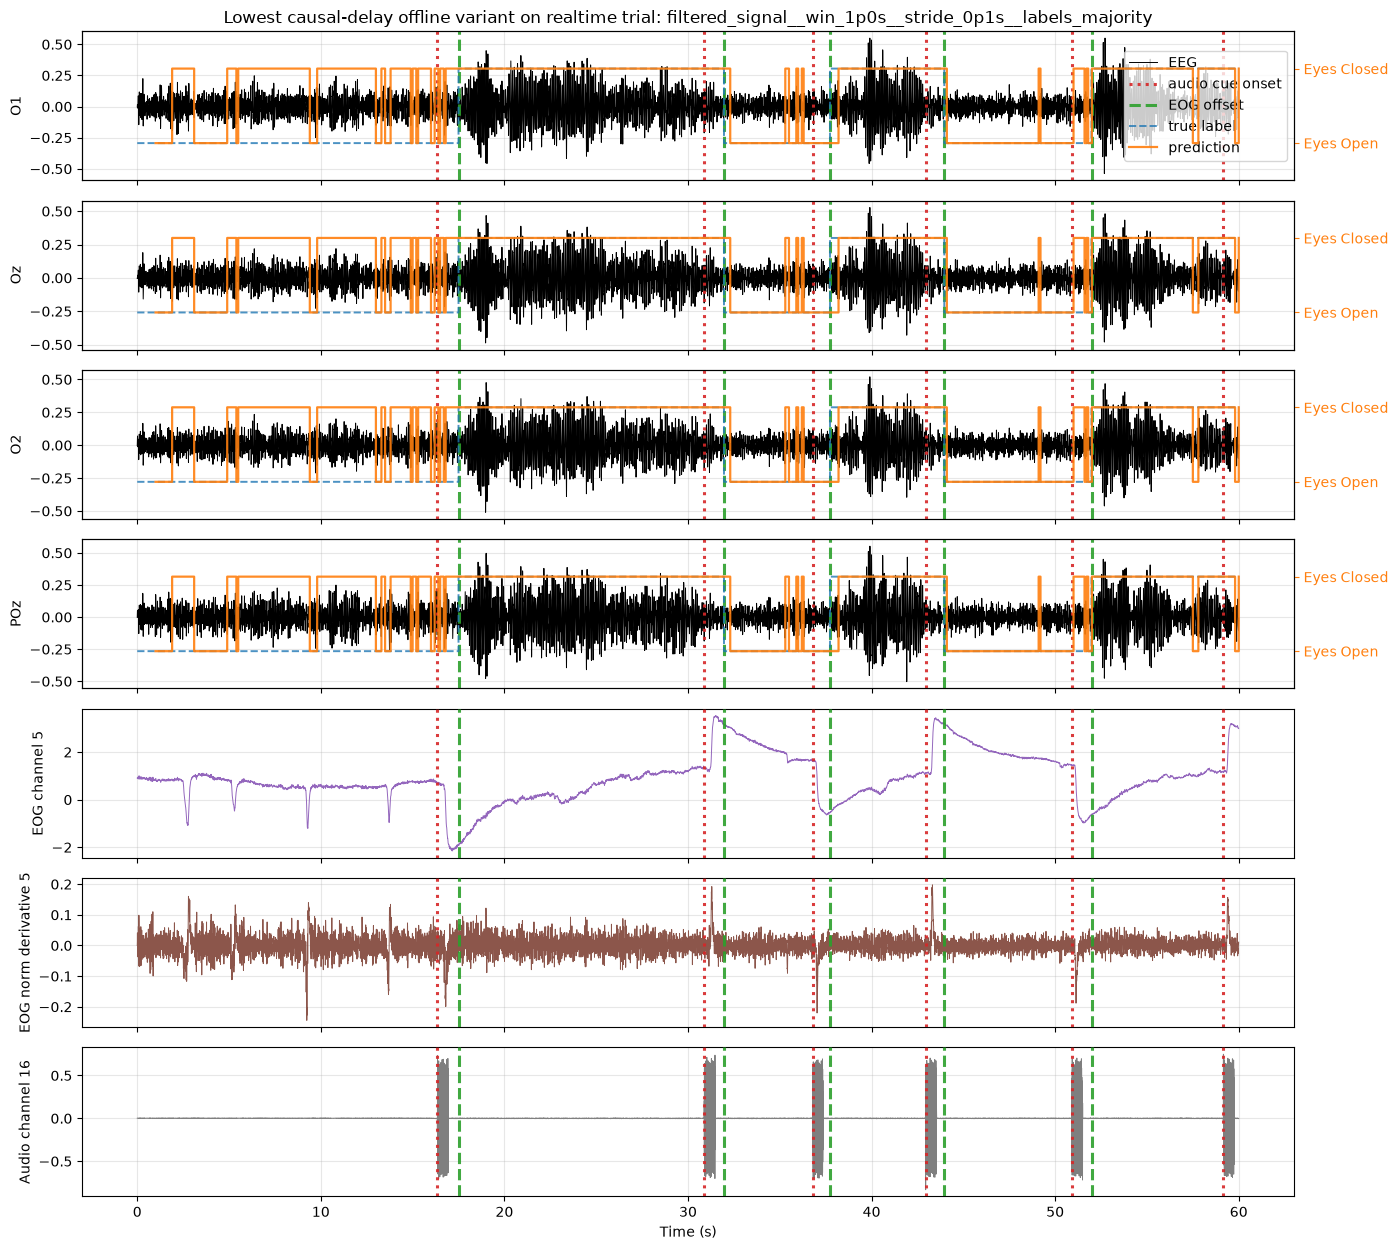

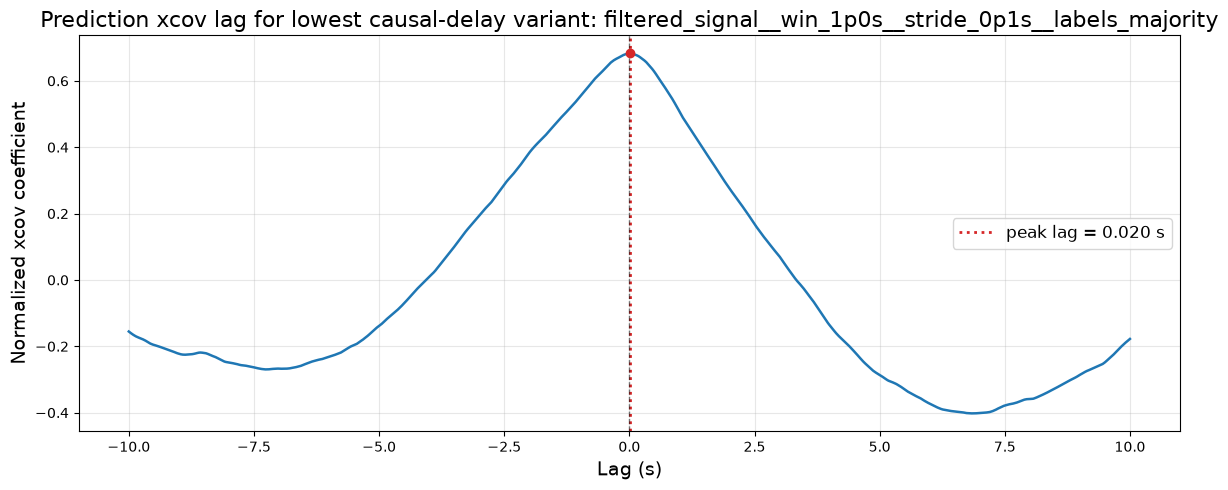

In [21]:
lowest_delay = select_lowest_causal_delay_variant(summary)
lowest_delay_artifacts = load_test_variant_artifacts(lowest_delay, TEST_LABELED_NPZ)
lowest_delay_paths = lowest_delay_artifacts['paths']
lowest_delay_predictions = lowest_delay_artifacts['predictions']
lowest_delay_cue_delay_summary = lowest_delay_artifacts['cue_delay_summary']
lowest_delay_xcov_delay_summary = lowest_delay_artifacts['xcov_delay_summary']
lowest_delay_xcov_curve = lowest_delay_artifacts['xcov_curve']

print('Lowest causal-delay variant:', lowest_delay['variant'])
print('Lowest causal xcov delay sec:', lowest_delay.get('test_xcov_delay_sec'))
print('Lowest causal-delay xcov peak coefficient:', lowest_delay.get('test_xcov_peak_coeff'))
print('Lowest causal-delay predictions:', lowest_delay_paths['prediction_csv'])
print('Lowest causal-delay aligned EEG/predictions:', lowest_delay_paths['aligned_prediction_csv'])

display(lowest_delay_predictions.tail())
if lowest_delay_cue_delay_summary is not None:
    display(lowest_delay_cue_delay_summary)
if lowest_delay_xcov_delay_summary is not None:
    display(lowest_delay_xcov_delay_summary)

fig, axes = plot_predictions_overlay(
    TEST_LABELED_NPZ,
    lowest_delay_predictions,
    max_duration_sec=PLOT_DURATION_SEC,
    channel_names=EEG_CHANNEL_NAMES,
    show_true_labels=True,
    legend_loc='center right',
)
axes[0].set_title(
    f"Lowest causal-delay offline variant on realtime trial: {lowest_delay['variant']}"
)

if lowest_delay_xcov_curve is not None and lowest_delay_xcov_delay_summary is not None:
    fig, ax = plot_xcov_curve(
        lowest_delay_xcov_curve,
        lowest_delay_xcov_delay_summary,
        title=f"Prediction xcov lag for lowest causal-delay variant: {lowest_delay['variant']}",
    )


## Inspect any variant by window, stride, and label mode

Set the window, stride, and label mode below to pull that exact sweep result. This is useful for comparing the xcov-ranked or delay-ranked winners against another variant while keeping the same trace plot, xcov plot, and summary tables.


Selected comparison variant: filtered_signal__win_1p0s__stride_0p05s__labels_majority
Selected comparison xcov delay sec: -0.06
Selected comparison xcov peak coefficient: 0.5417041672547007
Selected comparison predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline_eog\offline_eog_002_vs_003\sweeps\filtered_signal__win_1p0s__stride_0p05s__labels_majority\run_003__run_003_train_eog_offset_labeled_test_predictions.csv
Selected comparison aligned EEG/predictions: d:\BME\BCI\online_bci\online_eeg\runs_offline_eog\offline_eog_002_vs_003\sweeps\filtered_signal__win_1p0s__stride_0p05s__labels_majority\run_003__run_003_train_eog_offset_labeled_test_predictions_aligned_eeg.csv


,start_sample,end_sample,start_time_sec,end_time_sec,label,true_label,pred_label,correct,prob_Eyes Open,prob_Eyes Closed
5976,59760,59960,298.80,299.80,0,0,0,True,0.555943,0.444057
5977,59770,59970,298.85,299.85,0,0,0,True,0.913358,0.086642
5978,59780,59980,298.90,299.90,0,0,0,True,0.746909,0.253091
5979,59790,59990,298.95,299.95,0,0,0,True,0.911212,0.088788
5980,59800,60000,299.00,300.00,0,0,0,True,0.909534,0.090466


,n_cues,n_matched_first_correct,mean_cue_to_first_correct_sec,median_cue_to_first_correct_sec,n_matched_predicted_transition,mean_cue_to_predicted_transition_sec,median_cue_to_predicted_transition_sec,n_matched_sustained,mean_cue_to_sustained_prediction_sec,median_cue_to_sustained_prediction_sec
0,40,40,0.29075,0.04,29,1.145517,0.49,38,0.553947,0.1875


,target_label,target_label_name,prediction_signal_column,xcov_delay_sec,xcov_lag_samples,xcov_peak_coeff,max_lag_sec,n_valid_samples
0,1,Eyes Closed,prob_Eyes Closed,-0.06,-12,0.541704,10.0,59800


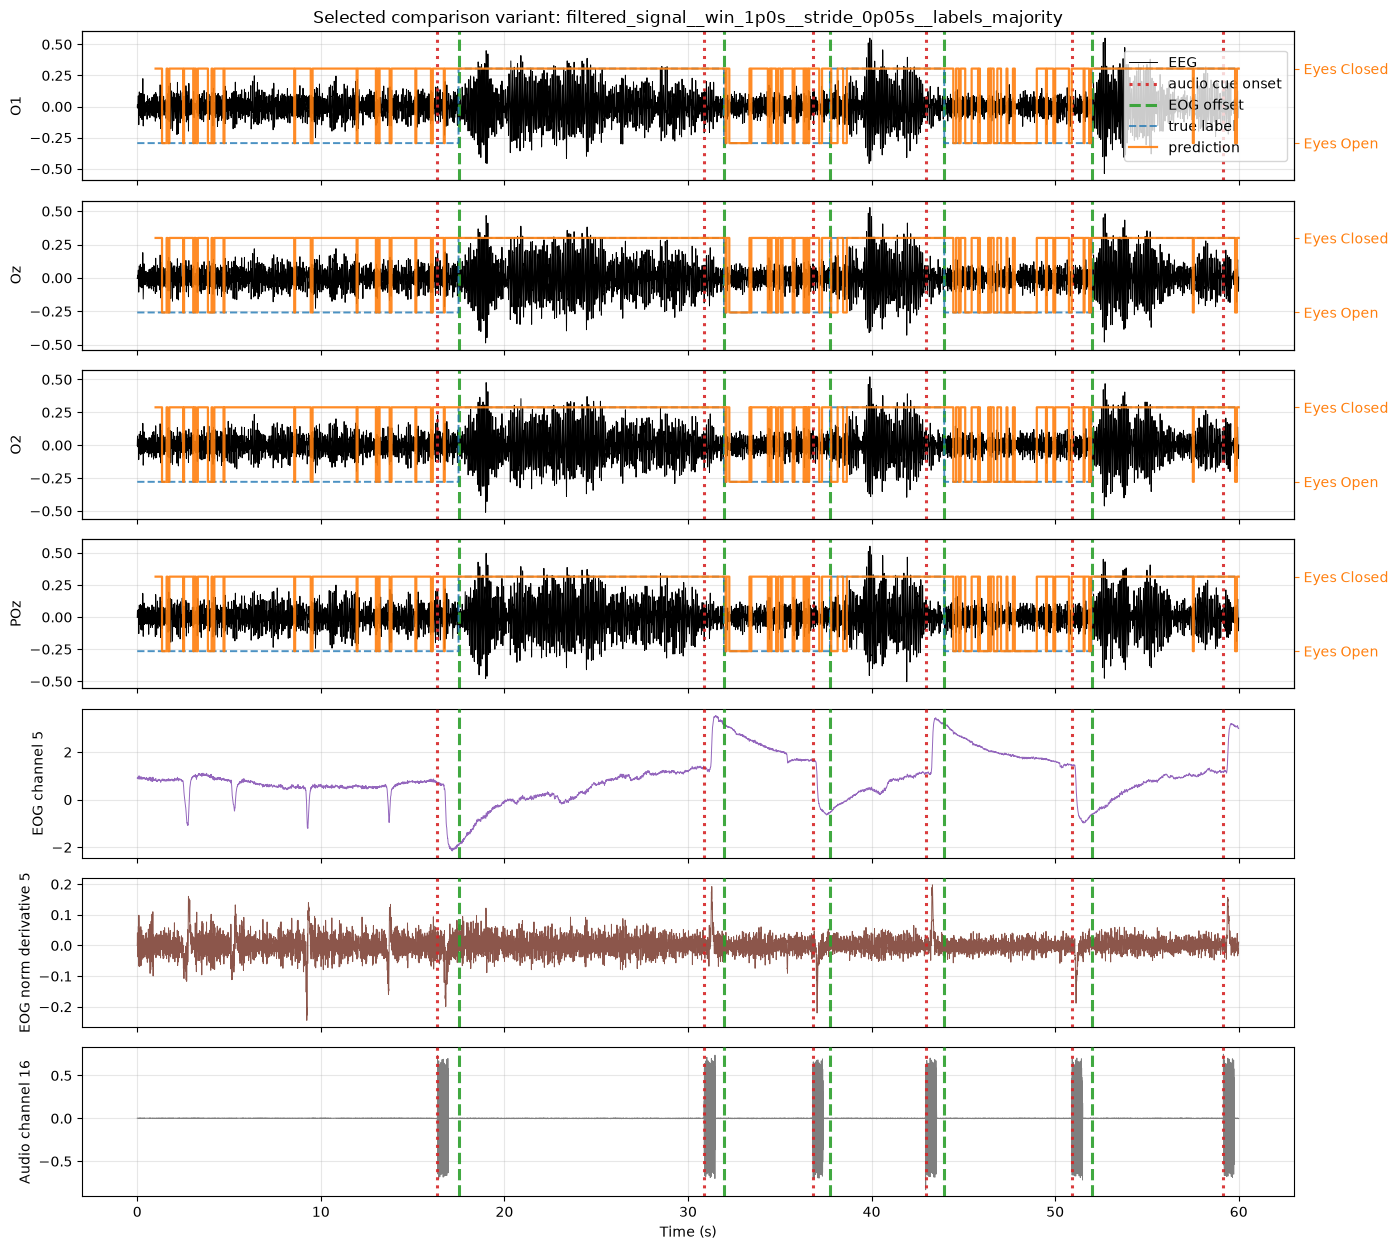

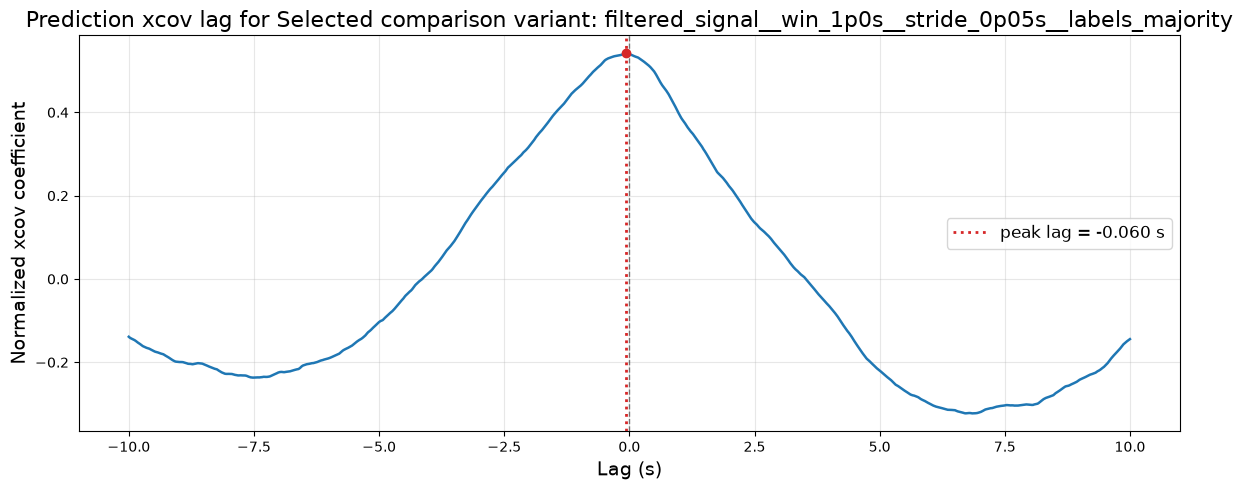

In [22]:
COMPARE_FEATURE_MODE = 'filtered_signal'
COMPARE_WINDOW_SEC = 1.0
COMPARE_STRIDE_SEC = 0.05
COMPARE_LABEL_MODE = 'majority'  # 'endpoint' or 'majority'

compare_result = plot_offline_variant_trace_and_xcov(
    summary=summary,
    labeled_npz=TEST_LABELED_NPZ,
    feature_mode=COMPARE_FEATURE_MODE,
    window_sec=COMPARE_WINDOW_SEC,
    stride_sec=COMPARE_STRIDE_SEC,
    label_mode=COMPARE_LABEL_MODE,
    channel_names=EEG_CHANNEL_NAMES,
    max_duration_sec=PLOT_DURATION_SEC,
    show_true_labels=True,
    legend_loc='center right',
    title_prefix='Selected comparison variant',
)
compare_row = compare_result['row']
compare_artifacts = compare_result['artifacts']
compare_paths = compare_artifacts['paths']

print('Selected comparison variant:', compare_row['variant'])
print('Selected comparison xcov delay sec:', compare_row.get('test_xcov_delay_sec'))
print('Selected comparison xcov peak coefficient:', compare_row.get('test_xcov_peak_coeff'))
print('Selected comparison predictions:', compare_paths['prediction_csv'])
print('Selected comparison aligned EEG/predictions:', compare_paths['aligned_prediction_csv'])

display(compare_artifacts['predictions'].tail())
if compare_artifacts['cue_delay_summary'] is not None:
    display(compare_artifacts['cue_delay_summary'])
if compare_artifacts['xcov_delay_summary'] is not None:
    display(compare_artifacts['xcov_delay_summary'])
